In [10]:
from scipy.stats import bernoulli, binom
from matplotlib.pyplot import bar, show, hist, grid, legend, xticks

nr_pasi = 10


def mers_aleator_axa(nr_pasi, p):
    pozitii = [0]
    for _ in range(nr_pasi):
        x = bernoulli.rvs(p)
        pas = 2 * x - 1
        pozitii.append(pozitii[-1] + pas)
    return pozitii


print(mers_aleator_axa(nr_pasi, 0.5));

[0, 1, 0, -1, 0, 1, 0, 1, 2, 1, 0]


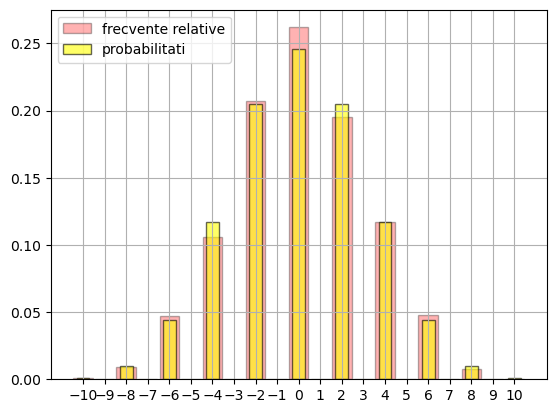

In [14]:
def sim_mers_aleator_axa(nr_pasi, p, nr_sim):
    pozitii_finale = [mers_aleator_axa(nr_pasi, p)[-1] for _ in range(nr_sim)]
    bin_edges = [i + 0.5 for i in range(-nr_pasi - 1, nr_pasi + 1)]
    hist(pozitii_finale, bin_edges, density=True, rwidth=0.9, align='mid', edgecolor='black',
         color='red', alpha=0.3, label="frecvente relative")

    distribution = dict([(k - (nr_pasi - k), binom.pmf(k, nr_pasi, p))
                         for k in range(nr_pasi + 1)])
    bar(distribution.keys(), distribution.values(), width=0.6, align='center',
        color='yellow', edgecolor='black', alpha=0.6, label='probabilitati')
    xticks(range(-nr_pasi, nr_pasi + 1))
    legend(loc='upper left')
    grid()
    show()


sim_mers_aleator_axa(nr_pasi, 0.5, nr_sim)

In [28]:
from scipy.stats import hypergeom, geom

nr_sim = 1000
p = sum([hypergeom.pmf(k, 49, 6, 6) for k in range(3, 7)])
nr_bile_necastigatoare = geom.rvs(p, size=nr_sim)

prob_estimari = sum([x >= 10 for x in nr_bile_necastigatoare]) / nr_sim

prob_teoretic =1-geom.pmf(9,p)


In [32]:
# prob_estimari
prob_teoretic

0.9839666521536035